In [7]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.text import Tokenizer

In [19]:
df = pd.read_csv('twitter.csv')
df.columns = df.columns.str.strip()
df['Sentiment'] = df['Sentiment'].str.strip().str.lower() 
df = df[df['Sentiment'].isin(['positive', 'neutral', 'negative'])]

In [20]:
X = df['Text'].values
y = df['Sentiment'].map({'negative': 0, 'neutral': 1, 'positive': 2}).values
y = to_categorical(y, num_classes=3)

In [21]:
tokenizer = Tokenizer(num_words=5000, oov_token="<OOV>")
tokenizer.fit_on_texts(X)
x_seq = tokenizer.texts_to_sequences(X)
x_pad = pad_sequences(x_seq, maxlen=100)

In [22]:
X_train, X_val, y_train, y_val = train_test_split(x_pad, y, test_size=0.2, random_state=42)

In [23]:
model = Sequential()
model.add(Embedding(input_dim=5000, output_dim=64, input_length=100))
model.add(LSTM(64))
model.add(Dense(3, activation='softmax'))

C:\Users\Om Shete\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [24]:
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [25]:
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=5, batch_size=64)

Epoch 1/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.2264 - loss: 1.1002 - val_accuracy: 0.6429 - val_loss: 1.0800
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.7547 - loss: 1.0751 - val_accuracy: 0.6429 - val_loss: 1.0586
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - accuracy: 0.6792 - loss: 1.0498 - val_accuracy: 0.6429 - val_loss: 1.0328
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.6792 - loss: 1.0203 - val_accuracy: 0.6429 - val_loss: 1.0003
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.6792 - loss: 0.9843 - val_accuracy: 0.6429 - val_loss: 0.9590


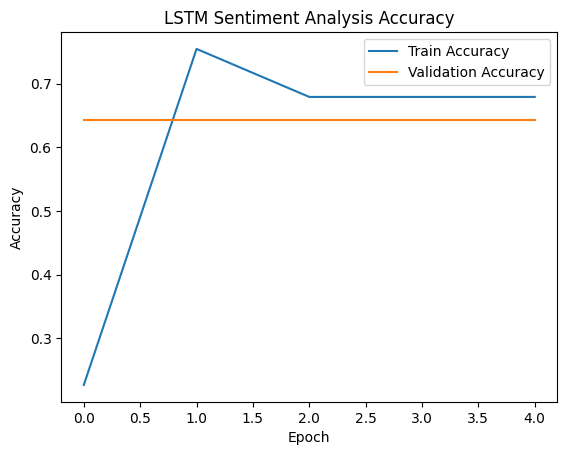

In [26]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('LSTM Sentiment Analysis Accuracy')
plt.show()
